In [47]:
import json

In [48]:
# Read raw data from logs
def read_log(fname):
    with open(fname, 'r') as file:
        data = json.load(file)
    return data

In [49]:
dataset = 'cifar10'
log_centralized = 'centralized_learning/centralized_learning.json'
log_fl = 'federated_learning/fl.json'
rst_centralized = read_log(log_centralized)
rst_fl = read_log(log_fl)

In [50]:
best_acc_centralized = max(rst_centralized['accuracy'])
best_acc_fl = max(rst_fl['accuracy'])
print(f"best_acc_centralized: {best_acc_centralized}, best_acc_fl: {best_acc_fl}")

best_acc_centralized: 0.6368, best_acc_fl: 0.65


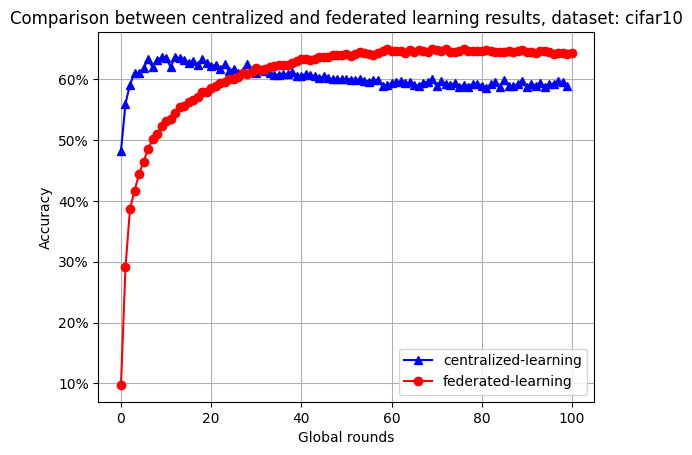

In [51]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

y_c = [x*100 for x in rst_centralized['accuracy']]
y_fl = [x*100 for x in rst_fl['accuracy']]
# y_c = rst_centralized['accuracy']
# y_fl = rst_fl['accuracy']

# Create the plot
x_c = np.array(range(len(rst_centralized['accuracy'])))
x_fl = np.array(range(len(rst_fl['accuracy'])))
plt.plot(x_c, y_c, label='centralized-learning', color='blue', marker='^')  # Plot first array
plt.plot(x_fl, y_fl, label='federated-learning', color='red', marker='o')   # Plot second array

# Format the y-axis as percentages
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0))

# Add labels and title
plt.xlabel('Global rounds')
plt.ylabel('Accuracy')
plt.title('Comparison between centralized and federated learning results, dataset: {}'.format(dataset))

# Add legend
plt.legend()

# Display the plot
plt.grid(True)  # Optional: Add grid